# Polars vs Pandas benchmark trên cùng dataset (CSV và Parquet), 10–20 triệu dòng

Dataset: NYC TLC Yellow Taxi Trip Records (2019).  
- Parquet: bản chính thức (NYC TLC / CloudFront).  
- CSV.gz: bản backup (DataTalksClub).  

Notebook tự chọn số tháng để tổng số dòng nằm trong khoảng 10–20 triệu (dựa trên Parquet metadata) và dùng đúng các tháng đó cho cả Parquet và CSV.


## 0) Cài thư viện (nếu thiếu)

Bạn có thể pin version theo môi trường của bạn; cell này chỉ để tham khảo.


In [1]:
!pip install polars pandas pyarrow psutil tqdm matplotlib


## 1) Import + in version

In [2]:
import os, time, gc
from pathlib import Path

import pandas as pd
import polars as pl
import psutil
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

print('pandas', pd.__version__)
print('polars', pl.__version__)
print('pyarrow', pa.__version__)
print('psutil', psutil.__version__)


/home/shinenolife/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


pandas 3.0.0
polars 1.37.1
pyarrow 23.0.0
psutil 7.2.2


## 2) Cấu hình dataset (2019, auto chọn tháng để đạt 10–20M rows)

- Parquet (official): `https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_YYYY-MM.parquet`
- CSV.gz (backup): `https://github.com/DataTalksClub/nyc-tlc-data/releases/download/yellow/yellow_tripdata_YYYY-MM.csv.gz`

Nếu máy yếu/RAM ít, giảm TARGET_MIN xuống (ví dụ 5_000_000).


In [22]:
PARQUET_BASE = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{ym}.parquet'
CSV_BASE     = 'https://github.com/DataTalksClub/nyc-tlc-data/releases/download/yellow/yellow_tripdata_{ym}.csv.gz'
ZONE_URL     = 'https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv'

TARGET_MIN = 30_000_000
TARGET_MAX = 40_000_000

# Auto thêm tháng cho tới khi đạt target
MONTHS_CANDIDATE = ['2019-01','2019-02','2019-03','2019-04','2019-05','2019-06']

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

def parquet_url(ym): return PARQUET_BASE.format(ym=ym)
def csv_url(ym):     return CSV_BASE.format(ym=ym)
def parquet_path(ym): return DATA_DIR / f'yellow_tripdata_{ym}.parquet'
def csv_path(ym):     return DATA_DIR / f'yellow_tripdata_{ym}.csv.gz'
ZONE_PATH = DATA_DIR / 'taxi_zone_lookup.csv'


## 3) Tải file (nếu chưa có)

In [23]:
import urllib.request

def download(url: str, dst: Path, chunk_size: int = 1024 * 1024):
    if dst.exists() and dst.stat().st_size > 0:
        return
    print('Download:', url)
    with urllib.request.urlopen(url) as r, open(dst, 'wb') as f:
        total = r.length
        pbar = tqdm(total=total, unit='B', unit_scale=True) if total else tqdm(unit='B', unit_scale=True)
        while True:
            chunk = r.read(chunk_size)
            if not chunk:
                break
            f.write(chunk)
            pbar.update(len(chunk))
        pbar.close()

download(ZONE_URL, ZONE_PATH)
print('Zone:', ZONE_PATH, 'MB=', round(ZONE_PATH.stat().st_size/1024**2, 2))


Download: https://d37ci6vzurychx.cloudfront.net/misc/taxi+_zone_lookup.csv


  0%|          | 0.00/12.3k [00:00<?, ?B/s]

Zone: data/taxi_zone_lookup.csv MB= 0.01


## 4) Chọn số tháng đủ 10–20 triệu dòng (dựa trên Parquet metadata)

Lấy num_rows trực tiếp từ Parquet metadata nên không cần đọc dữ liệu để đếm.


In [24]:
def parquet_num_rows(path: Path) -> int:
    pf = pq.ParquetFile(path)
    return pf.metadata.num_rows

selected_months = []
parquet_paths = []
csv_paths = []
total_rows = 0

for ym in MONTHS_CANDIDATE:
    p_path = parquet_path(ym)
    c_path = csv_path(ym)
    download(parquet_url(ym), p_path)
    n = parquet_num_rows(p_path)
    selected_months.append(ym)
    parquet_paths.append(str(p_path))
    total_rows += n
    # tải csv.gz cùng tháng để đảm bảo so sánh 2 format trên cùng dữ liệu
    download(csv_url(ym), c_path)
    csv_paths.append(str(c_path))
    print(f'{ym}: rows={n:,}  parquetMB={round(p_path.stat().st_size/1024**2,1)}  csvgzMB={round(c_path.stat().st_size/1024**2,1)}')
    if TARGET_MIN <= total_rows <= TARGET_MAX:
        break

print('\nSelected months:', selected_months)
print('Total rows (from parquet metadata):', f'{total_rows:,}')
print('Num files:', len(parquet_paths))


Download: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-01.parquet


  0%|          | 0.00/110M [00:00<?, ?B/s]

Download: https://github.com/DataTalksClub/nyc-tlc-data/releases/download/yellow/yellow_tripdata_2019-01.csv.gz


  0%|          | 0.00/134M [00:00<?, ?B/s]

2019-01: rows=7,696,617  parquetMB=105.3  csvgzMB=128.2
Download: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-02.parquet


...

2019-03: rows=7,866,620  parquetMB=110.6  csvgzMB=137.0
Download: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2019-04.parquet


  0%|          | 0.00/110M [00:00<?, ?B/s]

Download: https://github.com/DataTalksClub/nyc-tlc-data/releases/download/yellow/yellow_tripdata_2019-04.csv.gz


  0%|          | 0.00/136M [00:00<?, ?B/s]

2019-04: rows=7,475,949  parquetMB=105.0  csvgzMB=129.9

Selected months: ['2019-01', '2019-02', '2019-03', '2019-04']
Total rows (from parquet metadata): 30,088,556
Num files: 4


## 5) Cột và workload

Để công bằng giữa CSV và Parquet, mình dùng các cột số phổ biến và tránh cột datetime (CSV cần parse thêm).  
Workload B có join với zone_lookup để mô phỏng ETL thực tế.


In [25]:
zone_pd = pd.read_csv(ZONE_PATH)
zone_pl = pl.read_csv(ZONE_PATH)

USE_COLS = ['PULocationID','passenger_count','trip_distance','total_amount']
DTYPES_PD = {
    'PULocationID': 'Int32',
    'passenger_count': 'Float32',
    'trip_distance': 'Float32',
    'total_amount': 'Float32',
}

FILTER_DIST = 2.0
FILTER_AMOUNT = 0.0


## 6) Hàm benchmark (thời gian + RSS delta)

In [26]:
proc = psutil.Process(os.getpid())

def rss_mb():
    return proc.memory_info().rss / (1024**2)

def bench(name, fn, repeats=5):
    times, mems = [], []
    for _ in range(repeats):
        gc.collect()
        m0 = rss_mb()
        t0 = time.perf_counter()
        out = fn()
        t1 = time.perf_counter()
        m1 = rss_mb()
        times.append(t1 - t0)
        mems.append(max(0.0, m1 - m0))
        _ = out
        del out
    times_sorted = sorted(times)
    mems_sorted = sorted(mems)
    return {
        'name': name,
        'time_s_med': times_sorted[len(times_sorted)//2],
        'time_s_min': times_sorted[0],
        'mem_mb_med': mems_sorted[len(mems_sorted)//2],
    }


## 7) Test A: đọc file (chỉ cột cần)

So sánh 3 engine cho mỗi format:
- pandas
- polars eager
- polars lazy (scan + collect)


In [27]:
def pandas_read_parquet():
    return pd.read_parquet(parquet_paths, engine='pyarrow', columns=USE_COLS)

def polars_eager_read_parquet():
    return pl.read_parquet(parquet_paths, columns=USE_COLS)

def polars_lazy_read_parquet():
    return pl.scan_parquet(parquet_paths).select(USE_COLS).collect()

def pandas_read_csv():
    # pandas đọc nhiều file -> concat
    dfs = []
    for p in csv_paths:
        try:
            df = pd.read_csv(p, compression='gzip', usecols=USE_COLS, dtype=DTYPES_PD, engine='pyarrow')
        except Exception:
            df = pd.read_csv(p, compression='gzip', usecols=USE_COLS, dtype=DTYPES_PD)
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

def polars_eager_read_csv():
    # polars có thể đọc list path tùy version; dùng concat để chắc chắn
    return pl.concat([pl.read_csv(p, columns=USE_COLS) for p in csv_paths], how='vertical')

def polars_lazy_read_csv():
    lfs = [pl.scan_csv(p).select(USE_COLS) for p in csv_paths]
    return pl.concat(lfs, how='vertical').collect()


## 8) Test B: ETL end-to-end (read + filter + group_by + join + sort/top-k)

In [28]:
def pandas_etl_parquet():
    df = pd.read_parquet(parquet_paths, engine='pyarrow', columns=USE_COLS)
    df = df[(df['trip_distance'] > FILTER_DIST) & (df['total_amount'] > FILTER_AMOUNT)]
    g = (df.groupby('passenger_count', dropna=False)
           .agg(trips=('total_amount','size'), revenue=('total_amount','sum'))
           .reset_index())
    df2 = df[['PULocationID']].merge(zone_pd, left_on='PULocationID', right_on='LocationID', how='left')
    top10 = (df2.groupby('Zone', dropna=False).size().sort_values(ascending=False).head(10))
    return g, top10

def polars_eager_etl_parquet():
    df = pl.read_parquet(parquet_paths, columns=USE_COLS)
    df = df.filter((pl.col('trip_distance') > FILTER_DIST) & (pl.col('total_amount') > FILTER_AMOUNT))
    g = df.group_by('passenger_count').agg([pl.len().alias('trips'), pl.col('total_amount').sum().alias('revenue')])
    top10 = (df.select(['PULocationID'])
               .join(zone_pl, left_on='PULocationID', right_on='LocationID', how='left')
               .group_by('Zone').agg(pl.len().alias('trips'))
               .sort('trips', descending=True)
               .head(10))
    return g, top10

def polars_lazy_etl_parquet():
    lf = (pl.scan_parquet(parquet_paths)
            .select(USE_COLS)
            .filter((pl.col('trip_distance') > FILTER_DIST) & (pl.col('total_amount') > FILTER_AMOUNT)))
    g = (lf.group_by('passenger_count')
           .agg([pl.len().alias('trips'), pl.col('total_amount').sum().alias('revenue')])
           .collect())
    top10 = (lf.select(['PULocationID'])
              .join(zone_pl.lazy(), left_on='PULocationID', right_on='LocationID', how='left')
              .group_by('Zone').agg(pl.len().alias('trips'))
              .sort('trips', descending=True)
              .head(10)
              .collect())
    return g, top10

def pandas_etl_csv():
    # read CSV (concat)
    df = pandas_read_csv()
    df = df[(df['trip_distance'] > FILTER_DIST) & (df['total_amount'] > FILTER_AMOUNT)]
    g = (df.groupby('passenger_count', dropna=False)
           .agg(trips=('total_amount','size'), revenue=('total_amount','sum'))
           .reset_index())
    df2 = df[['PULocationID']].merge(zone_pd, left_on='PULocationID', right_on='LocationID', how='left')
    top10 = (df2.groupby('Zone', dropna=False).size().sort_values(ascending=False).head(10))
    return g, top10

def polars_eager_etl_csv():
    df = polars_eager_read_csv()
    df = df.filter((pl.col('trip_distance') > FILTER_DIST) & (pl.col('total_amount') > FILTER_AMOUNT))
    g = df.group_by('passenger_count').agg([pl.len().alias('trips'), pl.col('total_amount').sum().alias('revenue')])
    top10 = (df.select(['PULocationID'])
               .join(zone_pl, left_on='PULocationID', right_on='LocationID', how='left')
               .group_by('Zone').agg(pl.len().alias('trips'))
               .sort('trips', descending=True)
               .head(10))
    return g, top10

def polars_lazy_etl_csv():
    lfs = [pl.scan_csv(p).select(USE_COLS) for p in csv_paths]
    lf = pl.concat(lfs, how='vertical')
    lf = lf.filter((pl.col('trip_distance') > FILTER_DIST) & (pl.col('total_amount') > FILTER_AMOUNT))
    g = (lf.group_by('passenger_count')
           .agg([pl.len().alias('trips'), pl.col('total_amount').sum().alias('revenue')])
           .collect())
    top10 = (lf.select(['PULocationID'])
              .join(zone_pl.lazy(), left_on='PULocationID', right_on='LocationID', how='left')
              .group_by('Zone').agg(pl.len().alias('trips'))
              .sort('trips', descending=True)
              .head(10)
              .collect())
    return g, top10


## 9) Chạy benchmark và tạo bảng kết quả

In [29]:
results = []

# A) Read
results.append({**bench('A/read - parquet - pandas', pandas_read_parquet), 'workload':'read', 'format':'parquet', 'engine':'pandas'})
results.append({**bench('A/read - parquet - polars eager', polars_eager_read_parquet), 'workload':'read', 'format':'parquet', 'engine':'polars_eager'})
results.append({**bench('A/read - parquet - polars lazy', polars_lazy_read_parquet), 'workload':'read', 'format':'parquet', 'engine':'polars_lazy'})

results.append({**bench('A/read - csv - pandas', pandas_read_csv), 'workload':'read', 'format':'csv', 'engine':'pandas'})
results.append({**bench('A/read - csv - polars eager', polars_eager_read_csv), 'workload':'read', 'format':'csv', 'engine':'polars_eager'})
results.append({**bench('A/read - csv - polars lazy', polars_lazy_read_csv), 'workload':'read', 'format':'csv', 'engine':'polars_lazy'})

# B) ETL
results.append({**bench('B/etl - parquet - pandas', pandas_etl_parquet), 'workload':'etl', 'format':'parquet', 'engine':'pandas'})
results.append({**bench('B/etl - parquet - polars eager', polars_eager_etl_parquet), 'workload':'etl', 'format':'parquet', 'engine':'polars_eager'})
results.append({**bench('B/etl - parquet - polars lazy', polars_lazy_etl_parquet), 'workload':'etl', 'format':'parquet', 'engine':'polars_lazy'})

results.append({**bench('B/etl - csv - pandas', pandas_etl_csv), 'workload':'etl', 'format':'csv', 'engine':'pandas'})
results.append({**bench('B/etl - csv - polars eager', polars_eager_etl_csv), 'workload':'etl', 'format':'csv', 'engine':'polars_eager'})
results.append({**bench('B/etl - csv - polars lazy', polars_lazy_etl_csv), 'workload':'etl', 'format':'csv', 'engine':'polars_lazy'})

res_df = pd.DataFrame(results)
res_df = res_df.sort_values(['workload','format','time_s_med'])
res_df


,name,time_s_med,time_s_min,mem_mb_med,workload,format,engine
11,B/etl - csv - polars lazy,4.044388,3.757752,0.000000,etl,csv,polars_lazy
10,B/etl - csv - polars eager,6.412809,6.000693,110.281250,etl,csv,polars_eager
9,B/etl - csv - pandas,10.540035,10.161700,0.000000,etl,csv,pandas
7,B/etl - parquet - polars eager,0.729322,0.700854,77.367188,etl,parquet,polars_eager
8,B/etl - parquet - polars lazy,0.850259,0.795863,14.003906,etl,parquet,polars_lazy
6,B/etl - parquet - pandas,3.795717,3.731752,0.000000,etl,parquet,pandas
5,A/read - csv - polars lazy,1.232859,1.153388,7.007812,read,csv,polars_lazy
4,A/read - csv - polars eager,5.283607,5.225405,55.269531,read,csv,polars_eager
3,A/read - csv - pandas,8.673673,7.104455,1162.464844,read,csv,pandas
2,A/read - parquet - polars lazy,0.173396,0.104705,4.433594,read,parquet,polars_lazy


## 10) Vẽ biểu đồ thời gian chạy (median)

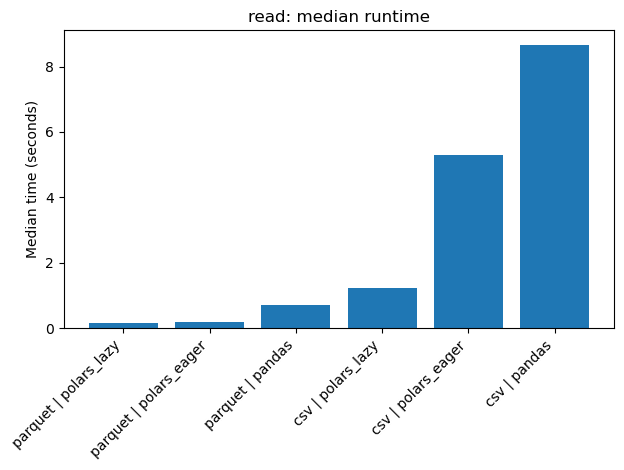

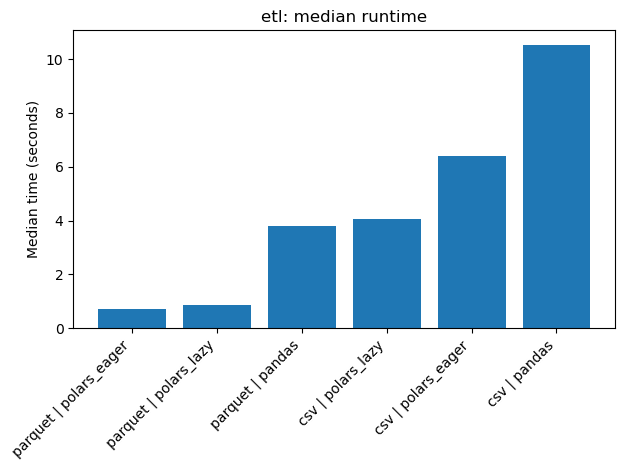

In [30]:
def plot_time(res_df, workload):
    sub = res_df[res_df['workload'] == workload].copy()
    # tạo label gọn
    sub['label'] = sub['format'] + ' | ' + sub['engine']
    sub = sub.sort_values('time_s_med')
    plt.figure()
    plt.bar(sub['label'], sub['time_s_med'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median time (seconds)')
    plt.title(f'{workload}: median runtime')
    plt.tight_layout()
    plt.show()

plot_time(res_df, 'read')
plot_time(res_df, 'etl')


## 11) Vẽ biểu đồ memory delta (median RSS)

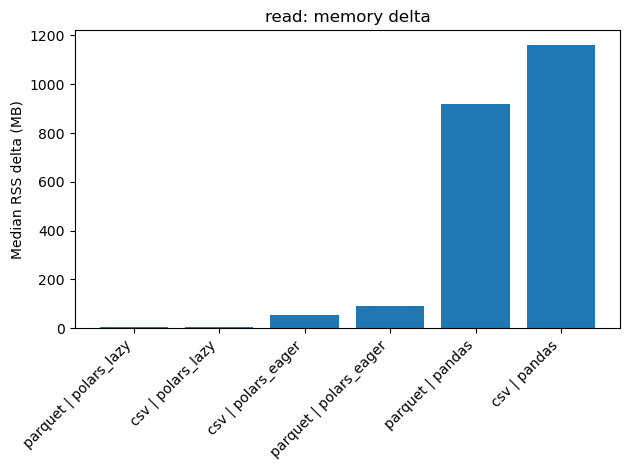

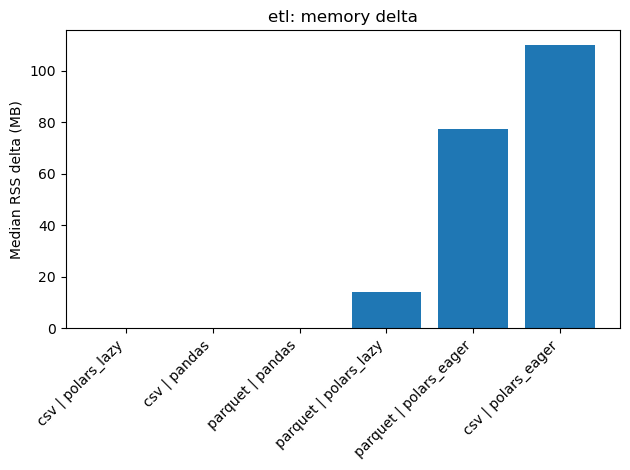

In [31]:
def plot_mem(res_df, workload):
    sub = res_df[res_df['workload'] == workload].copy()
    sub['label'] = sub['format'] + ' | ' + sub['engine']
    sub = sub.sort_values('mem_mb_med')
    plt.figure()
    plt.bar(sub['label'], sub['mem_mb_med'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Median RSS delta (MB)')
    plt.title(f'{workload}: memory delta')
    plt.tight_layout()
    plt.show()

plot_mem(res_df, 'read')
plot_mem(res_df, 'etl')


## 12) Bảng speedup so với pandas (cùng format + workload)

In [32]:
def speedup(res_df):
    out = []
    for (workload, fmt), g in res_df.groupby(['workload','format']):
        base = g[g['engine']=='pandas']['time_s_med'].iloc[0]
        gg = g.copy()
        gg['speedup_vs_pandas'] = base / gg['time_s_med']
        out.append(gg)
    return pd.concat(out).sort_values(['workload','format','speedup_vs_pandas'], ascending=[True,True,False])

speed_df = speedup(res_df)
speed_df[['workload','format','engine','time_s_med','speedup_vs_pandas','mem_mb_med']]


,workload,format,engine,time_s_med,speedup_vs_pandas,mem_mb_med
11,etl,csv,polars_lazy,4.044388,2.606089,0.000000
10,etl,csv,polars_eager,6.412809,1.643591,110.281250
9,etl,csv,pandas,10.540035,1.000000,0.000000
7,etl,parquet,polars_eager,0.729322,5.204443,77.367188
8,etl,parquet,polars_lazy,0.850259,4.464188,14.003906
6,etl,parquet,pandas,3.795717,1.000000,0.000000
5,read,csv,polars_lazy,1.232859,7.035412,7.007812
4,read,csv,polars_eager,5.283607,1.641620,55.269531
3,read,csv,pandas,8.673673,1.000000,1162.464844
2,read,parquet,polars_lazy,0.173396,4.081858,4.433594


## 13) (Tuỳ chọn) Xem query plan của Polars lazy (để thấy pushdown)

In [21]:
lf_demo = (
    pl.scan_parquet(parquet_paths)
      .select(USE_COLS)
      .filter((pl.col('trip_distance') > FILTER_DIST) & (pl.col('total_amount') > FILTER_AMOUNT))
      .group_by('passenger_count')
      .agg([pl.len().alias('trips'), pl.col('total_amount').sum().alias('revenue')])
)
print(lf_demo.explain())


AGGREGATE[maintain_order: false]
  [len().alias("trips"), col("total_amount").sum().alias("revenue")] BY [col("passenger_count")]
  FROM
  Parquet SCAN [data/yellow_tripdata_2019-01.parquet, data/yellow_tripdata_2019-02.parquet]
  PROJECT 3/19 COLUMNS
  SELECTION: [([(col("total_amount")) > (0.0)]) & ([(col("trip_distance")) > (2.0)])]
  ESTIMATED ROWS: 15393234
